# # Amazon Reviews — NLP Pipeline
# **Goal:** Build a support ticket system using sentence embeddings, vector database, semantic search, clustering, and topic classification.
#
# **Dataset:** `amazon.csv` — 1,465 Amazon India product reviews



In [ ]:
# Step 1 — Install Packages
# Run this cell once. After it finishes, restart the kernel, then run from Step 2 onward
import sys
!{sys.executable} -m pip install sentence-transformers chromadb umap-learn scikit-learn matplotlib seaborn plotly nltk --quiet

In [ ]:
# Step 2 — Import Libraries

import os
import re
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import matplotlib.patches as mpatches
from pathlib import Path
from collections import Counter

import nltk
from nltk.corpus import stopwords
from sentence_transformers import SentenceTransformer
import chromadb
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.feature_extraction.text import TfidfVectorizer
import umap
from IPython.display import display

warnings.filterwarnings("ignore")
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)

print("All libraries imported successfully")

All libraries imported successfully


In [ ]:
# Step 3 — Load the Dataset
# Import the files module for uploading local files
from google.colab import files

# Upload the amazon.csv file from your local machine
print("Please upload the 'amazon.csv' file:")
uploaded = files.upload()

# Get the name of the uploaded file
file_name = list(uploaded.keys())[0]

# Read the uploaded CSV file into a DataFrame
df = pd.read_csv(file_name)

print(f"✅ Loaded {len(df):,} rows  |  Columns: {list(df.columns)}")
display(df.head())

Please upload the 'amazon.csv' file:


Saving amazon.csv to amazon.csv
✅ Loaded 1,465 rows  |  Columns: ['product_id', 'product_name', 'category', 'discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count', 'about_product', 'user_id', 'user_name', 'review_id', 'review_title', 'review_content', 'img_link', 'product_link']


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [ ]:
# ## Step 4 — Explore the Raw Data

# Before cleaning, let's understand the structure and quality of the data.

print("Data types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nCategory distribution:")
print(df["category"].str.split("|").str[0].value_counts())

print("\nSample rating values:")
print(df["rating"].value_counts().head(8))

Data types:
product_id             object
product_name           object
category               object
discounted_price       object
actual_price           object
discount_percentage    object
rating                 object
rating_count           object
about_product          object
user_id                object
user_name              object
review_id              object
review_title           object
review_content         object
img_link               object
product_link           object
dtype: object

Missing values per column:
product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

Category distribution:
category
Electronics         

In [ ]:
# Step 5 — Explode Multi-Reviewer Rows into Individual Reviews

# Each product row stores multiple reviewers as comma-separated values.
# We split them and pair each `review_title[i]` with `review_content[i]` to get one row per review.
# We also clean numeric fields: remove `₹`, commas from prices, and `%` from discount.

URL_RE = re.compile(r"https?://\S+|www\.\S+")

def parse_price(val):
    try:
        return float(re.sub(r"[₹,\s]", "", str(val)))
    except ValueError:
        return None

records = []

for _, row in df.iterrows():

    titles = [t.strip() for t in str(row["review_title"]).split(",")
              if len(t.strip()) > 4 and not t.strip().startswith("http")]

    contents = [c.strip() for c in str(row["review_content"]).split(",")
                if len(c.strip()) > 10 and not URL_RE.match(c.strip())]

    if not titles or not contents:
        continue

    try:
        rating = float(str(row["rating"]).strip())
    except ValueError:
        continue

    try:
        disc_pct = float(str(row["discount_percentage"]).replace("%", "").strip())
    except ValueError:
        disc_pct = None

    category = str(row["category"]).split("|")[0].strip()

    for i in range(min(len(titles), len(contents))):
        text = f"{titles[i]}. {contents[i]}"
        if len(text) < 20:
            continue
        records.append({
            "doc_id"          : f"{row['product_id']}_{i}",
            "product_id"      : row["product_id"],
            "product_name"    : str(row["product_name"])[:80],
            "category"        : category,
            "rating"          : rating,
            "discounted_price": parse_price(row["discounted_price"]),
            "actual_price"    : parse_price(row["actual_price"]),
            "discount_pct"    : disc_pct,
            "review_title"    : titles[i],
            "review_content"  : contents[i],
            "text"            : text[:400],
        })

df = pd.DataFrame(records).reset_index(drop=True)

print(f"Individual reviews extracted: {len(df)}")
display(df.head(4))

Individual reviews extracted: 10518


,doc_id,product_id,product_name,category,rating,discounted_price,actual_price,discount_pct,review_title,review_content,text
0,B07JW9H4J1_0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories,4.2,399.0,1099.0,64.0,Satisfied,Looks durable Charging is fine tooNo complains,Satisfied. Looks durable Charging is fine tooN...
1,B07JW9H4J1_1,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories,4.2,399.0,1099.0,64.0,Charging is really fast,Charging is really fast,Charging is really fast. Charging is really fast
2,B07JW9H4J1_2,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories,4.2,399.0,1099.0,64.0,Value for money,good product.,Value for money. good product.
3,B07JW9H4J1_3,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories,4.2,399.0,1099.0,64.0,Product review,Till now satisfied with the quality.,Product review. Till now satisfied with the qu...


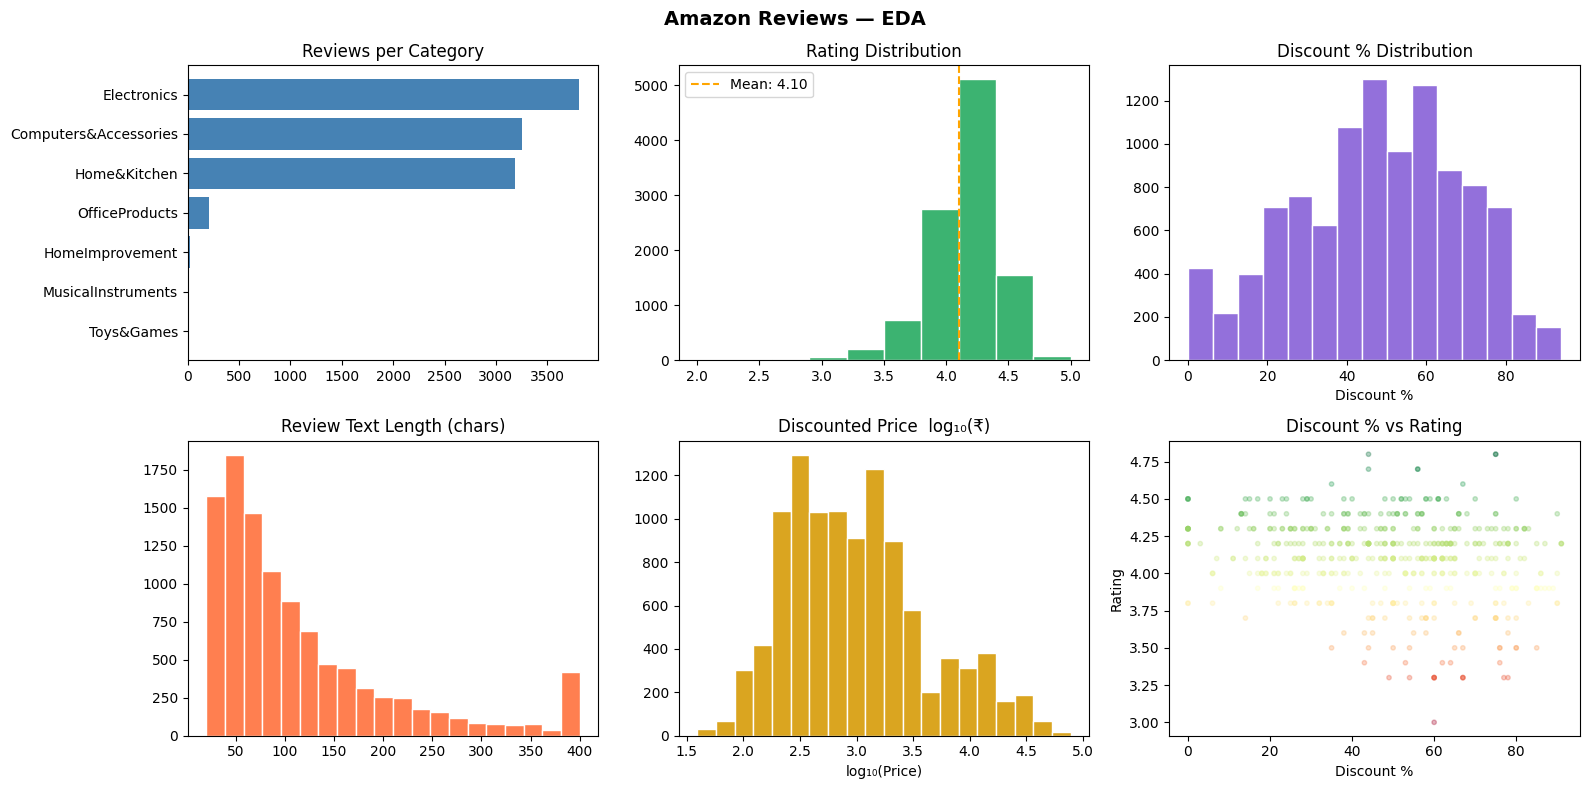

Numeric summary:
         rating  discounted_price  discount_pct
count  10518.00          10518.00      10518.00
mean       4.10           3142.12         47.94
std        0.28           6873.19         21.34
min        2.00             39.00          0.00
25%        4.00            337.00         33.00
50%        4.10            849.00         50.00
75%        4.30           2071.50         63.00
max        5.00          77990.00         94.00


In [ ]:
# Step 6 — Exploratory Data Analysis

# Let's visualise the key distributions in the dataset.

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Amazon Reviews — EDA", fontsize=14, fontweight="bold")

# Reviews per category
cat_counts = df["category"].value_counts().head(7)
axes[0, 0].barh(cat_counts.index, cat_counts.values, color="steelblue")
axes[0, 0].set_title("Reviews per Category")
axes[0, 0].invert_yaxis()

# Rating distribution
axes[0, 1].hist(df["rating"], bins=10, color="mediumseagreen", edgecolor="white")
axes[0, 1].axvline(df["rating"].mean(), color="orange", linestyle="--",
                   label=f"Mean: {df['rating'].mean():.2f}")
axes[0, 1].set_title("Rating Distribution")
axes[0, 1].legend()

# Discount % distribution
axes[0, 2].hist(df["discount_pct"].dropna(), bins=15, color="mediumpurple", edgecolor="white")
axes[0, 2].set_title("Discount % Distribution")
axes[0, 2].set_xlabel("Discount %")

# Review text length
df["text_len"] = df["text"].str.len()
axes[1, 0].hist(df["text_len"], bins=20, color="coral", edgecolor="white")
axes[1, 0].set_title("Review Text Length (chars)")

# Price distribution
prices = df["discounted_price"].dropna()
prices = prices[prices > 0]
axes[1, 1].hist(np.log10(prices), bins=20, color="goldenrod", edgecolor="white")
axes[1, 1].set_title("Discounted Price  log₁₀(₹)")
axes[1, 1].set_xlabel("log₁₀(Price)")

# Rating vs Discount scatter
sample = df.dropna(subset=["discount_pct"]).sample(min(500, len(df)), random_state=42)
axes[1, 2].scatter(sample["discount_pct"], sample["rating"],
                   alpha=0.3, s=10, c=sample["rating"], cmap="RdYlGn")
axes[1, 2].set_title("Discount % vs Rating")
axes[1, 2].set_xlabel("Discount %")
axes[1, 2].set_ylabel("Rating")

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=120, bbox_inches="tight")
plt.show()

print("Numeric summary:")
print(df[["rating", "discounted_price", "discount_pct"]].describe().round(2))

Row 0
  Before: Satisfied. Looks durable Charging is fine tooNo complains
  After : satisfied looks durable charging fine toono complains

Row 5
  Before: Good product. Good quality
  After : good product good quality

Row 20
  Before: Good product. Good product
  After : good product good product

Average tokens before: 20.6
Average tokens after : 11.6  (43.7% reduction)


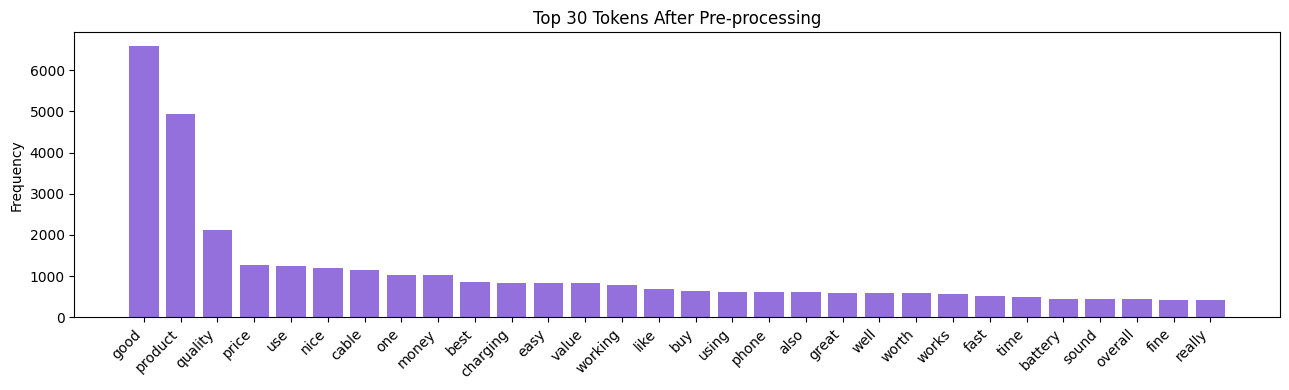

In [ ]:
# Step 7 — Text Pre-processing

# Before generating embeddings we clean the review text:
# 1. Lowercase everything
# 2. Remove URLs
# 3. Strip punctuation
# 4. Remove stopwords (common words like "the", "is", "a")
# 5. Drop tokens shorter than 3 characters

STOP_WORDS = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = URL_RE.sub(" ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    tokens = [t for t in text.split() if t not in STOP_WORDS and len(t) > 2]
    return " ".join(tokens).strip()

df["clean_text"] = df["text"].apply(clean_text)

# Show before / after for 3 reviews
for i in [0, 5, 20]:
    print(f"Row {i}")
    print(f"  Before: {df.loc[i, 'text'][:90]}")
    print(f"  After : {df.loc[i, 'clean_text'][:90]}")
    print()

before_avg = df["text"].str.split().str.len().mean()
after_avg  = df["clean_text"].str.split().str.len().mean()
print(f"Average tokens before: {before_avg:.1f}")
print(f"Average tokens after : {after_avg:.1f}  ({(1 - after_avg/before_avg)*100:.1f}% reduction)")

# ### Most frequent tokens after cleaning


all_tokens = " ".join(df["clean_text"]).split()
top30 = Counter(all_tokens).most_common(30)
words, counts = zip(*top30)

plt.figure(figsize=(13, 4))
plt.bar(words, counts, color="mediumpurple")
plt.xticks(rotation=45, ha="right")
plt.title("Top 30 Tokens After Pre-processing")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("top30_tokens.png", dpi=120, bbox_inches="tight")
plt.show()



modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding 500 reviews...


Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Embedding matrix shape: (500, 384)
Vector norm (should be ~1.0): 1.0000


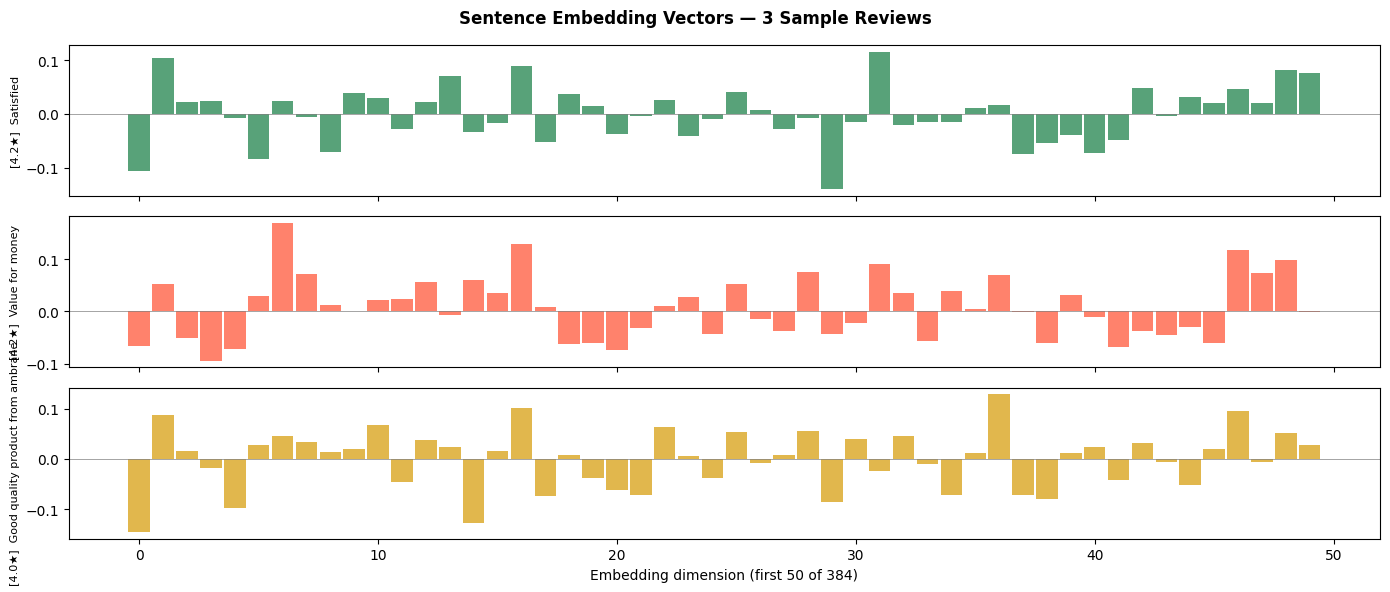

In [ ]:
# Step 8 — Generate Sentence Embeddings

# A **sentence embedding** converts a piece of text into a fixed-length numeric vector.
# Reviews that have similar meaning end up close together in this vector space.

# We use `all-MiniLM-L6-v2` from the `sentence-transformers` library:
# - Free, no API key needed
# - Produces **384-dimensional** vectors
# - Runs on CPU in about 15 seconds for 500 reviews
#
# Change `EMBED_LIMIT` to process more reviews (up to `len(df)`).

EMBED_LIMIT = 500   # increase this to process more reviews

embed_model = SentenceTransformer("all-MiniLM-L6-v2")

df_work = df.iloc[:EMBED_LIMIT].copy().reset_index(drop=True)

print(f"Embedding {len(df_work)} reviews...")

embeddings = embed_model.encode(
    df_work["clean_text"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True,
)

df_work["embedding"] = list(embeddings)

print(f"Embedding matrix shape: {embeddings.shape}")
print(f"Vector norm (should be ~1.0): {np.linalg.norm(embeddings[0]):.4f}")

# ### Visualise embedding vectors
# Each bar shows one dimension of the 384-dim vector. Positive values push toward that semantic direction, negative away from it.

fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)

for i, (ax, idx, color) in enumerate(zip(axes, [0, 2, 9], ["seagreen", "tomato", "goldenrod"])):
    label = f"[{df_work.loc[idx, 'rating']}★]  {df_work.loc[idx, 'review_title'][:50]}"
    ax.bar(range(50), embeddings[idx][:50], color=color, alpha=0.8, width=0.9)
    ax.set_ylabel(label, fontsize=8)
    ax.axhline(0, color="grey", linewidth=0.5)

axes[-1].set_xlabel("Embedding dimension (first 50 of 384)")
fig.suptitle("Sentence Embedding Vectors — 3 Sample Reviews", fontweight="bold")
plt.tight_layout()
plt.savefig("embedding_vectors.png", dpi=120, bbox_inches="tight")
plt.show()

# A **vector database** stores embeddings alongside metadata and lets you search by meaning rather than exact keywords.

# We use **ChromaDB** with a `PersistentClient` so the index is saved to disk and survives kernel restarts.

# The index uses **HNSW** (Hierarchical Navigable Small World) — a graph-based structure that finds approximate nearest neighbours in O(log n) time.

# Each document stored has:
# - `id` — unique string per review
# - `embedding` — 384-dim vector
# - `document` — original review text
# - `metadata` — category, rating, price, product name


In [ ]:
# Step 9 — Build a Vector Database with ChromaDB

CHROMA_DIR = r"D:\OneDrive - University of Arizona\Desktop\MSBA-UoA\Real Projects\NLP Based Insights\chroma_db"
COLLECTION  = "amazon_reviews"

chroma_client = chromadb.PersistentClient(path=CHROMA_DIR)

# Delete and recreate for a clean run
try:
    chroma_client.delete_collection(COLLECTION)
except Exception:
    pass

collection = chroma_client.create_collection(
    name=COLLECTION,
    metadata={"hnsw:space": "cosine"},
)

# Add documents in batches of 100
BATCH = 100
for start in range(0, len(df_work), BATCH):
    batch = df_work.iloc[start:start + BATCH]
    emb   = embeddings[start:start + BATCH]

    collection.add(
        ids        = batch["doc_id"].tolist(),
        embeddings = emb.tolist(),
        documents  = batch["text"].tolist(),
        metadatas  = [
            {
                "category"        : r["category"],
                "rating"          : float(r["rating"]),
                "discounted_price": float(r["discounted_price"]) if r["discounted_price"] else 0.0,
                "discount_pct"    : float(r["discount_pct"]) if r["discount_pct"] else 0.0,
                "product_name"    : r["product_name"][:60],
                "review_title"    : r["review_title"][:60],
            }
            for _, r in batch.iterrows()
        ],
    )
    print(f"  Indexed {min(start + BATCH, len(df_work))} / {len(df_work)}", end="\r")

print(f"\nTotal documents in vector index: {collection.count()}")
print(f"Index saved to: {CHROMA_DIR}")


# Peek at the stored index

peek = collection.peek(limit=3)
for i in range(len(peek["ids"])):
    print(f"ID       : {peek['ids'][i]}")
    print(f"Text     : {peek['documents'][i][:80]}")
    print(f"Metadata : {peek['metadatas'][i]}")
    print(f"Vec[:4]  : {np.round(peek['embeddings'][i][:4], 4)}")
    print()


Total documents in vector index: 500
Index saved to: D:\OneDrive - University of Arizona\Desktop\MSBA-UoA\Real Projects\NLP Based Insights\chroma_db
ID       : B07JW9H4J1_0
Text     : Satisfied. Looks durable Charging is fine tooNo complains
Metadata : {'discounted_price': 399.0, 'rating': 4.2, 'discount_pct': 64.0, 'category': 'Computers&Accessories', 'review_title': 'Satisfied', 'product_name': 'Wayona Nylon Braided USB to Lightning Fast Charging and Data'}
Vec[:4]  : [-0.1065  0.104   0.0223  0.0246]

ID       : B07JW9H4J1_1
Text     : Charging is really fast. Charging is really fast
Metadata : {'discount_pct': 64.0, 'review_title': 'Charging is really fast', 'discounted_price': 399.0, 'rating': 4.2, 'category': 'Computers&Accessories', 'product_name': 'Wayona Nylon Braided USB to Lightning Fast Charging and Data'}
Vec[:4]  : [ 0.0261  0.0684 -0.0168  0.0464]

ID       : B07JW9H4J1_2
Text     : Value for money. good product.
Metadata : {'discount_pct': 64.0, 'discounted_price': 399

# Semantic search works by:
# 1. Embedding the query into the same 384-dim vector space
# 2. Computing **cosine similarity** between the query vector and every stored vector
# 3. Returning the top-k most similar reviews

# **Cosine similarity** = A · B / (‖A‖ × ‖B‖), ranges from -1 (opposite) to +1 (identical).

# ChromaDB returns distance, so `similarity = 1 - distance`.

# Unlike SQL `LIKE '%fast charging%'`, semantic search also finds "rapid charge", "quick power up", "turbo charging" — without any keyword overlap.


In [ ]:
# Step 10 — Semantic Search

def semantic_search(query, top_k=5, category=None, min_rating=None, max_price=None):
    """Search the vector DB by meaning. Returns a DataFrame of results."""

    qvec = embed_model.encode([query], normalize_embeddings=True)[0].tolist()

    # Build optional metadata filters
    conditions = []
    if category   is not None: conditions.append({"category":         {"$eq":  category}})
    if min_rating is not None: conditions.append({"rating":           {"$gte": min_rating}})
    if max_price  is not None: conditions.append({"discounted_price": {"$lte": max_price}})

    where = ({"$and": conditions} if len(conditions) > 1
             else conditions[0]   if len(conditions) == 1
             else None)

    results = collection.query(
        query_embeddings=[qvec],
        n_results=top_k,
        where=where,
        include=["documents", "metadatas", "distances"],
    )

    rows = []
    for doc, meta, dist in zip(results["documents"][0],
                                results["metadatas"][0],
                                results["distances"][0]):
        rows.append({
            "similarity" : round(1 - dist, 4),
            "review"     : doc[:90],
            "category"   : meta["category"],
            "rating"     : meta["rating"],
            "price"      : f"₹{meta['discounted_price']:.0f}",
        })

    return pd.DataFrame(rows)

## Run example queries


Query: 'fast charging cable'  


,similarity,review,category,rating,price
0,0.9158,Not a fast charging cable. Product is super,Computers&Accessories,4.1,₹159
1,0.8406,fast charge. Worth buying this cable,Computers&Accessories,4.2,₹970
2,0.8306,Fast Charging as original. this cable actually...,Computers&Accessories,4.2,₹350
3,0.7772,1.5 m का केबल मेरे लिए बहुत ही लाभदायक है ।. q...,Computers&Accessories,4.1,₹177



Query: 'product broke after one week'  


,similarity,review,category,rating,price
0,0.5420,Working one. It's a good product.,Electronics,3.7,₹230
1,0.5278,Good one. Poor quality! Stopped working in a m...,Electronics,3.7,₹179
2,0.5070,Ok product. Ok type product. Not very sturdy,Computers&Accessories,3.3,₹333
3,0.4996,Good product. working fine,Computers&Accessories,4.0,₹249



Query: 'excellent value for money'  


...

,similarity,review,category,rating,price
0,0.5021,No Box!!!. Good product,Electronics,4.2,₹199
1,0.4603,Doesn't fit properly. which I always faced in ...,Computers&Accessories,4.1,₹199
2,0.4589,It's a good product. that if TV is damaged in ...,Electronics,4.3,₹19999
3,0.4307,Value for money. The cable did not come in a b...,Electronics,4.2,₹199



Query: 'warranty and support issue'  


,similarity,review,category,rating,price
0,0.4871,No issues. Working fine,Electronics,3.7,₹279
1,0.4303,Long durable.. Build quality is good and it is...,Computers&Accessories,4.1,₹177
2,0.4119,Genuine product. Received in good condition an...,Computers&Accessories,4.3,₹599
3,0.3991,Quality and service is good.. Quality of yhe c...,Computers&Accessories,4.2,₹970



Query: 'good audio earphones'  {'category': 'Electronics', 'min_rating': 4.0}


,similarity,review,category,rating,price
0,0.6056,Sound quality. LG was always Good,Electronics,4.3,₹13490
1,0.4931,Value for money. good service but sound qualit...,Electronics,4.3,₹13490
2,0.4884,Go for it without thinking twice.. Amazing pic...,Electronics,4.2,₹13999
3,0.4844,Sound is very low another brand comparing in b...,Electronics,4.3,₹13490


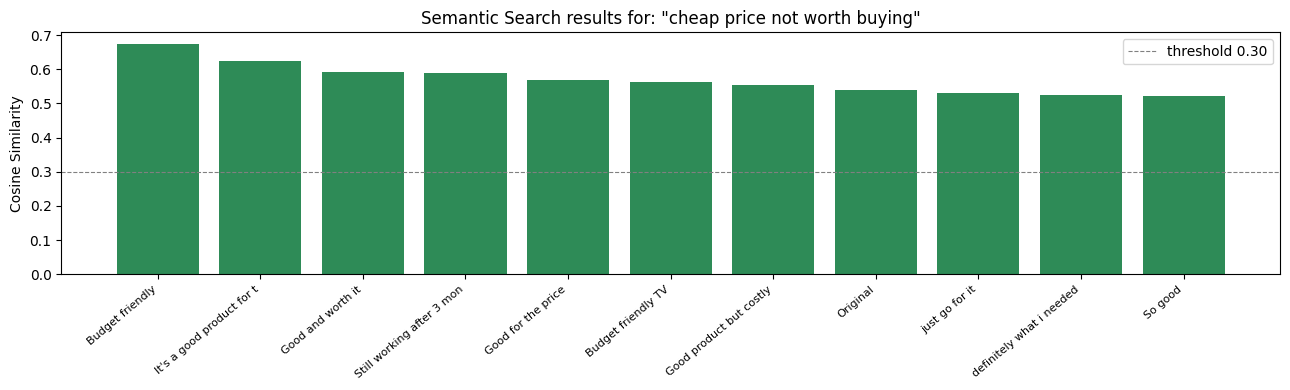

In [ ]:
queries = [
    ("fast charging cable",          {}),
    ("product broke after one week",  {}),
    ("excellent value for money",     {}),
    ("damaged box wrong item",        {}),
    ("warranty and support issue",    {}),
    ("good audio earphones",          {"category": "Electronics", "min_rating": 4.0}),
]

for query, filters in queries:
    print(f"\nQuery: '{query}'  {filters if filters else ''}")
    display(semantic_search(query, top_k=4, **filters))

# Similarity scores — bar chart

query = "cheap price not worth buying"
qvec  = embed_model.encode([query], normalize_embeddings=True)[0].tolist()
res   = collection.query(query_embeddings=[qvec], n_results=12,
                         include=["metadatas", "distances"])

sims  = [round(1 - d, 4) for d in res["distances"][0]]
lbls  = [m["review_title"][:25] for m in res["metadatas"][0]]
cols  = ["seagreen" if s > 0.45 else "goldenrod" if s > 0.25 else "tomato" for s in sims]

plt.figure(figsize=(13, 4))
plt.bar(lbls, sims, color=cols)
plt.xticks(rotation=40, ha="right", fontsize=8)
plt.ylabel("Cosine Similarity")
plt.title(f'Semantic Search results for: "{query}"')
plt.axhline(0.3, color="grey", linestyle="--", linewidth=0.8, label="threshold 0.30")
plt.legend()
plt.tight_layout()
plt.savefig("semantic_search.png", dpi=120, bbox_inches="tight")
plt.show()


# **K-Means clustering** on embeddings automatically groups reviews by topic — with no labelled training data.

# **How it works:**
# 1. Pick k starting centroids randomly
# 2. Assign each review to its nearest centroid (cosine distance)
# 3. Recompute centroids as the mean of their assigned reviews
# 4. Repeat until stable

# We use the **elbow method** (inertia) and **silhouette score** to find the best k.


Finding best k...
  k=2  inertia=345  silhouette=0.0706
  k=3  inertia=330  silhouette=0.0485
  k=4  inertia=318  silhouette=0.0643
  k=5  inertia=311  silhouette=0.0612
  k=6  inertia=309  silhouette=0.0516
  k=7  inertia=304  silhouette=0.0435
  k=8  inertia=298  silhouette=0.0484
  k=9  inertia=295  silhouette=0.0484
  k=10  inertia=290  silhouette=0.0503


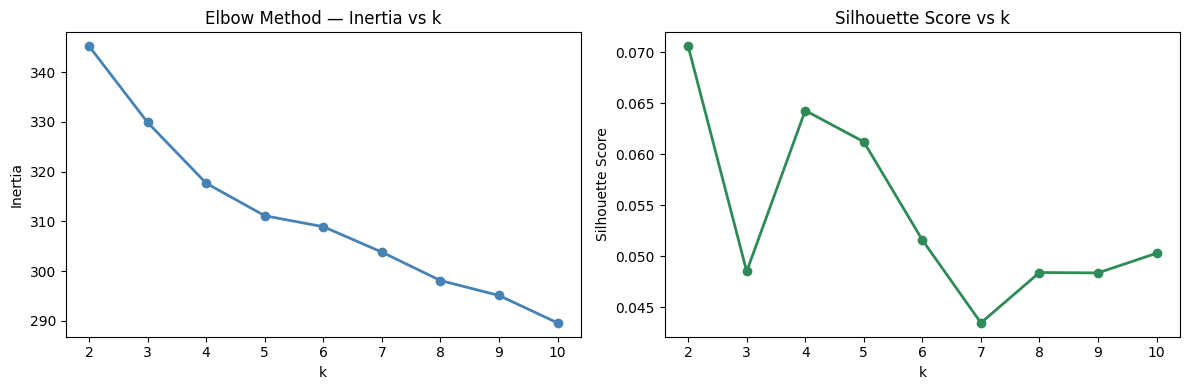


Best k by silhouette score: 2
Cluster 0  (225 reviews, avg rating 4.15)
  - Satisfied
  - Charging is really fast
  - Good quality

Cluster 1  (275 reviews, avg rating 4.16)
  - Value for money
  - Product review
  - Good product

Cluster 0: ['cable', 'charging', 'good', 'fast', 'product', 'fast charging', 'quality', 'charger', 'one', 'price']
Cluster 1: ['good', 'product', 'good product', 'quality', 'working', 'money', 'price', 'value money', 'value', 'nice']
Fitting UMAP (about 30 seconds)...


Interactive chart saved to umap_clusters.html


In [ ]:
# Step 11 — Cluster Complaints with K-Means

inertias, sil_scores = [], []
K_RANGE = range(2, 11)

print("Finding best k...")
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(embeddings)
    inertias.append(km.inertia_)
    score = silhouette_score(embeddings, km.labels_, sample_size=min(300, len(embeddings)))
    sil_scores.append(score)
    print(f"  k={k}  inertia={km.inertia_:,.0f}  silhouette={score:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(K_RANGE, inertias, "o-", color="steelblue", linewidth=2)
ax1.set_title("Elbow Method — Inertia vs k")
ax1.set_xlabel("k"); ax1.set_ylabel("Inertia")

ax2.plot(K_RANGE, sil_scores, "o-", color="seagreen", linewidth=2)
ax2.set_title("Silhouette Score vs k")
ax2.set_xlabel("k"); ax2.set_ylabel("Silhouette Score")

plt.tight_layout()
plt.savefig("elbow_silhouette.png", dpi=120, bbox_inches="tight")
plt.show()

BEST_K = list(K_RANGE)[sil_scores.index(max(sil_scores))]
print(f"\nBest k by silhouette score: {BEST_K}")

# Fit final K-Means model and inspect clusters

kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init="auto")
kmeans.fit(embeddings)
df_work["cluster"] = kmeans.labels_

for cl in sorted(df_work["cluster"].unique()):
    group = df_work[df_work["cluster"] == cl]
    print(f"Cluster {cl}  ({len(group)} reviews, avg rating {group['rating'].mean():.2f})")
    for title in group["review_title"].head(3):
        print(f"  - {title}")
    print()


# Extract top keywords per cluster using TF-IDF

tfidf      = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
tfidf_mat  = tfidf.fit_transform(df_work["clean_text"])
feat_names = np.array(tfidf.get_feature_names_out())

cluster_keywords = {}
for cl in sorted(df_work["cluster"].unique()):
    idx      = df_work[df_work["cluster"] == cl].index
    mean_vec = tfidf_mat[idx].mean(axis=0).A1
    top10    = feat_names[mean_vec.argsort()[-10:][::-1]].tolist()
    cluster_keywords[cl] = top10
    print(f"Cluster {cl}: {top10}")

# ### UMAP — visualise clusters in 2D

# **UMAP** reduces 384-dimensional embeddings to 2D for visualisation.
# It preserves the neighbourhood structure — reviews that were close in 384-dim space remain close in 2D.


print("Fitting UMAP (about 30 seconds)...")

reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                    metric="cosine", random_state=42)
umap_2d = reducer.fit_transform(embeddings)

df_work["umap_x"] = umap_2d[:, 0]
df_work["umap_y"] = umap_2d[:, 1]

fig = px.scatter(
    df_work,
    x="umap_x", y="umap_y",
    color="cluster",
    hover_data={"review_title": True, "category": True,
                "rating": True, "umap_x": False, "umap_y": False},
    title=f"UMAP 2D Projection — {BEST_K} K-Means Clusters ({len(df_work)} reviews)",
    template="plotly_dark",
    color_continuous_scale="Turbo",
    width=900, height=550,
)
fig.update_traces(marker=dict(size=5, opacity=0.75))
fig.write_html("umap_clusters.html")
fig.show()
print("Interactive chart saved to umap_clusters.html")



# We classify each review into one of 6 topics **without any labelled training data**.
#
# **How it works:**
# 1. Write a short description of each topic label
# 2. Embed those descriptions with the same model
# 3. Assign each review to the label whose embedding has the highest cosine similarity
#
# This works because sentence-transformers place semantically similar text close together — even across different phrasings.

Classifying all reviews...

Topic distribution:
topic
Product Performance       186
Positive Feedback         147
Value for Money            83
Quality Issue              70
Delivery and Packaging      9
Customer Service            5
Name: count, dtype: int64


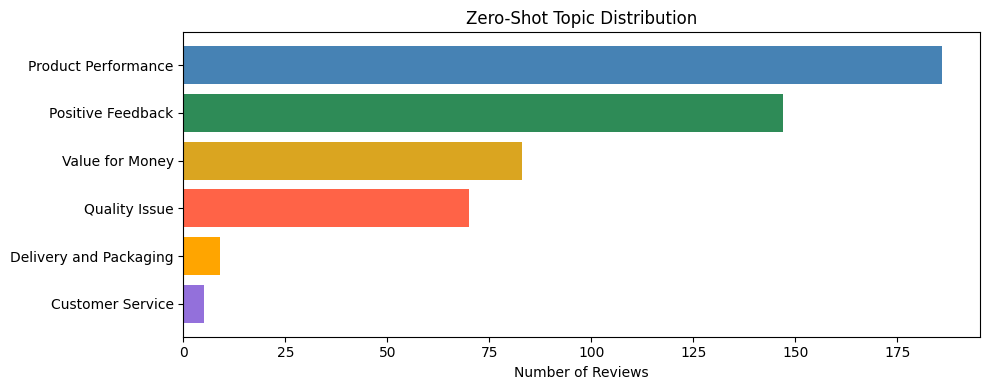

Sample classifications:

[Positive Feedback           ] [4.0★]  Go for it. I like it . Looks last long.
[Positive Feedback           ] [4.0★]  its good. Product quality is good
[Positive Feedback           ] [4.2★]  Good product. WiFi networks very quickly and easily.6. The overall sig
[Quality Issue               ] [4.2★]  Good product. even a braided cable stop working after a year
[Value for Money             ] [4.2★]  Cheap and best. If you have the trust of Amazon basics then go for it.
[Customer Service            ] [4.3★]  Floor stand does not come with it .... They product did not come with 
[Positive Feedback           ] [4.0★]  Worth it!. It does the job really well. No complaints regarding the ch
[Product Performance         ] [4.0★]  The cable quality is best and charging pin is at right position to sta
[Product Performance         ] [4.3★]  Charging Speeds Could Be Better. the cable overall is actually pretty 
[Positive Feedback           ] [4.2★]  Good product. Good quali

In [ ]:
# Step 12 — Zero-Shot Topic Classification

TOPIC_LABELS = [
    "Quality Issue: product broke defective not durable poor build cheap material",
    "Product Performance: fast charging speed compatible works well efficient data sync",
    "Value for Money: affordable price worth it good deal overpriced expensive budget",
    "Positive Feedback: excellent highly recommend satisfied love it great product happy",
    "Delivery and Packaging: damaged packaging late delivery wrong item courier shipping",
    "Customer Service: warranty claim return refund support response after sales service",
]
TOPIC_NAMES = [t.split(":")[0].strip() for t in TOPIC_LABELS]

label_vecs = embed_model.encode(TOPIC_LABELS, normalize_embeddings=True)

def classify_topic(text):
    vec = embed_model.encode([text], normalize_embeddings=True)[0]
    return TOPIC_NAMES[int(np.argmax(label_vecs @ vec))]

def topic_scores(text):
    vec  = embed_model.encode([text], normalize_embeddings=True)[0]
    sims = label_vecs @ vec
    return {TOPIC_NAMES[i]: round(float(sims[i]), 4) for i in range(len(TOPIC_NAMES))}

print("Classifying all reviews...")
df_work["topic"] = df_work["text"].apply(classify_topic)

print("\nTopic distribution:")
print(df_work["topic"].value_counts())


# Topic distribution chart

TOPIC_COLORS = {
    "Quality Issue":        "tomato",
    "Product Performance":  "steelblue",
    "Value for Money":      "goldenrod",
    "Positive Feedback":    "seagreen",
    "Delivery and Packaging": "orange",
    "Customer Service":     "mediumpurple",
}

td = df_work["topic"].value_counts()

plt.figure(figsize=(10, 4))
plt.barh(td.index, td.values,
         color=[TOPIC_COLORS.get(t, "grey") for t in td.index])
plt.xlabel("Number of Reviews")
plt.title("Zero-Shot Topic Distribution")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("topic_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

# Sample predictions

print("Sample classifications:\n")
for _, row in df_work.sample(10, random_state=7).iterrows():
    print(f"[{row['topic']:<28}] [{row['rating']}★]  {row['text'][:70]}")

# Confidence scores for individual reviews

print("Confidence scores for 3 sample reviews:\n")
for i in [0, 10, 25]:
    row = df_work.loc[i]
    print(f"Review: {row['text'][:80]}")
    scores = topic_scores(row["text"])
    for topic, score in sorted(scores.items(), key=lambda x: -x[1]):
        bar = "█" * int(score * 25)
        print(f"  {topic:<30} {score:.3f}  {bar}")
    print()



# **RAG (Retrieval-Augmented Generation)** combines vector search with classification:

# 1. **Clean** the incoming ticket text
# 2. **Embed** it into 384-dim space
# 3. **Retrieve** the most similar past reviews from ChromaDB
# 4. **Classify** topic, sentiment, and priority
# 5. **Recommend** an action for the support team

# In production you would pass the retrieved context to an LLM (GPT or Claude) for richer responses.

In [ ]:
# Step 13 — Full RAG Pipeline (Retrieve, Classify, Recommend)

def get_sentiment(text):
    text = text.lower()
    pos = sum(text.count(w) for w in
              ("good","great","excellent","perfect","love","best","recommend","satisfied","fast","works"))
    neg = sum(text.count(w) for w in
              ("broke","defect","poor","bad","worst","disappoint","damage","wrong","late","useless","issue","problem"))
    return "Positive" if pos > neg + 1 else "Negative" if neg > pos else "Neutral"

ACTION_MAP = {
    "Quality Issue":          "Route to Quality Control team for defect review.",
    "Product Performance":    "Send product spec sheet and compatibility guide.",
    "Value for Money":        "Offer discount coupon or price-match if within policy.",
    "Positive Feedback":      "Flag for marketing team as testimonial candidate.",
    "Delivery and Packaging": "Raise claim with logistics partner and arrange replacement.",
    "Customer Service":       "Escalate to senior agent for warranty processing.",
}

def rag_pipeline(ticket, top_k=3):
    """Clean → Embed → Retrieve from ChromaDB → Classify → Recommend."""

    clean = clean_text(ticket)
    vec   = embed_model.encode([clean], normalize_embeddings=True)[0].tolist()

    res = collection.query(
        query_embeddings=[vec],
        n_results=top_k,
        include=["documents", "metadatas", "distances"],
    )

    retrieved = [
        {
            "text"      : doc[:80],
            "similarity": round(1 - dist, 4),
            "category"  : meta["category"],
            "rating"    : meta["rating"],
        }
        for doc, meta, dist in zip(res["documents"][0],
                                   res["metadatas"][0],
                                   res["distances"][0])
    ]

    scores    = topic_scores(ticket)
    topic     = max(scores, key=scores.get)
    sentiment = get_sentiment(ticket)
    avg_rating= np.mean([r["rating"] for r in retrieved]) if retrieved else 3.0

    if avg_rating <= 2.0 or (sentiment == "Negative" and
       topic in ("Quality Issue", "Delivery and Packaging", "Customer Service")):
        priority = "HIGH"
    elif avg_rating >= 4.5 and sentiment == "Positive":
        priority = "LOW"
    else:
        priority = "MEDIUM"

    return {
        "ticket"   : ticket,
        "topic"    : topic,
        "sentiment": sentiment,
        "priority" : priority,
        "action"   : ACTION_MAP.get(topic, "Assign to general support queue."),
        "retrieved": retrieved,
    }

# Test the pipeline on 6 sample tickets

test_tickets = [
    "The USB cable stopped working completely after just 5 days. Very poor build quality.",
    "Delivery took 3 weeks and the box was completely crushed when it arrived.",
    "Amazing product! Charges my phone so fast. Exactly as described. Will buy again.",
    "The price jumped from ₹199 to ₹599 for the exact same product. Very misleading.",
    "I raised a warranty claim 2 weeks ago and still have not received any response.",
    "Product quality is average. Not bad but not great either. Packaging was fine.",
]

priority_icon  = {"HIGH": "🔴", "MEDIUM": "🟡", "LOW": "🟢"}
sentiment_icon = {"Positive": "😊", "Negative": "😞", "Neutral": "😐"}

for ticket in test_tickets:
    r = rag_pipeline(ticket)
    print(f"Ticket    : {r['ticket'][:75]}")
    print(f"Topic     : {r['topic']}")
    print(f"Sentiment : {sentiment_icon[r['sentiment']]} {r['sentiment']}   Priority: {priority_icon[r['priority']]} {r['priority']}")
    print(f"Action    : {r['action']}")
    print("Retrieved :")
    for rv in r["retrieved"]:
        print(f"  [{rv['similarity']:.3f}] [{rv['rating']}★]  {rv['text'][:60]}")
    print()

Ticket    : The USB cable stopped working completely after just 5 days. Very poor build
Topic     : Quality Issue
Sentiment : 😞 Negative   Priority: 🔴 HIGH
Action    : Route to Quality Control team for defect review.
Retrieved :
  [0.647] [3.9★]  Average quality. Very good item strong and useful USB cableV
  [0.647] [3.9★]  Average quality. Very good item strong and useful USB cableV
  [0.601] [4.3★]  Got a used type c to c cable and the xable was damaged. I am

Ticket    : Delivery took 3 weeks and the box was completely crushed when it arrived.
Topic     : Delivery and Packaging
Sentiment : 😐 Neutral   Priority: 🟡 MEDIUM
Action    : Raise claim with logistics partner and arrange replacement.
Retrieved :
  [0.458] [4.3★]  Very nice. correct delivery
  [0.424] [4.2★]  Value for money. The cable did not come in a box. There is n
  [0.407] [4.2★]  No Box!!!. Good product

Ticket    : Amazing product! Charges my phone so fast. Exactly as described. Will buy a
Topic     : Product Performan

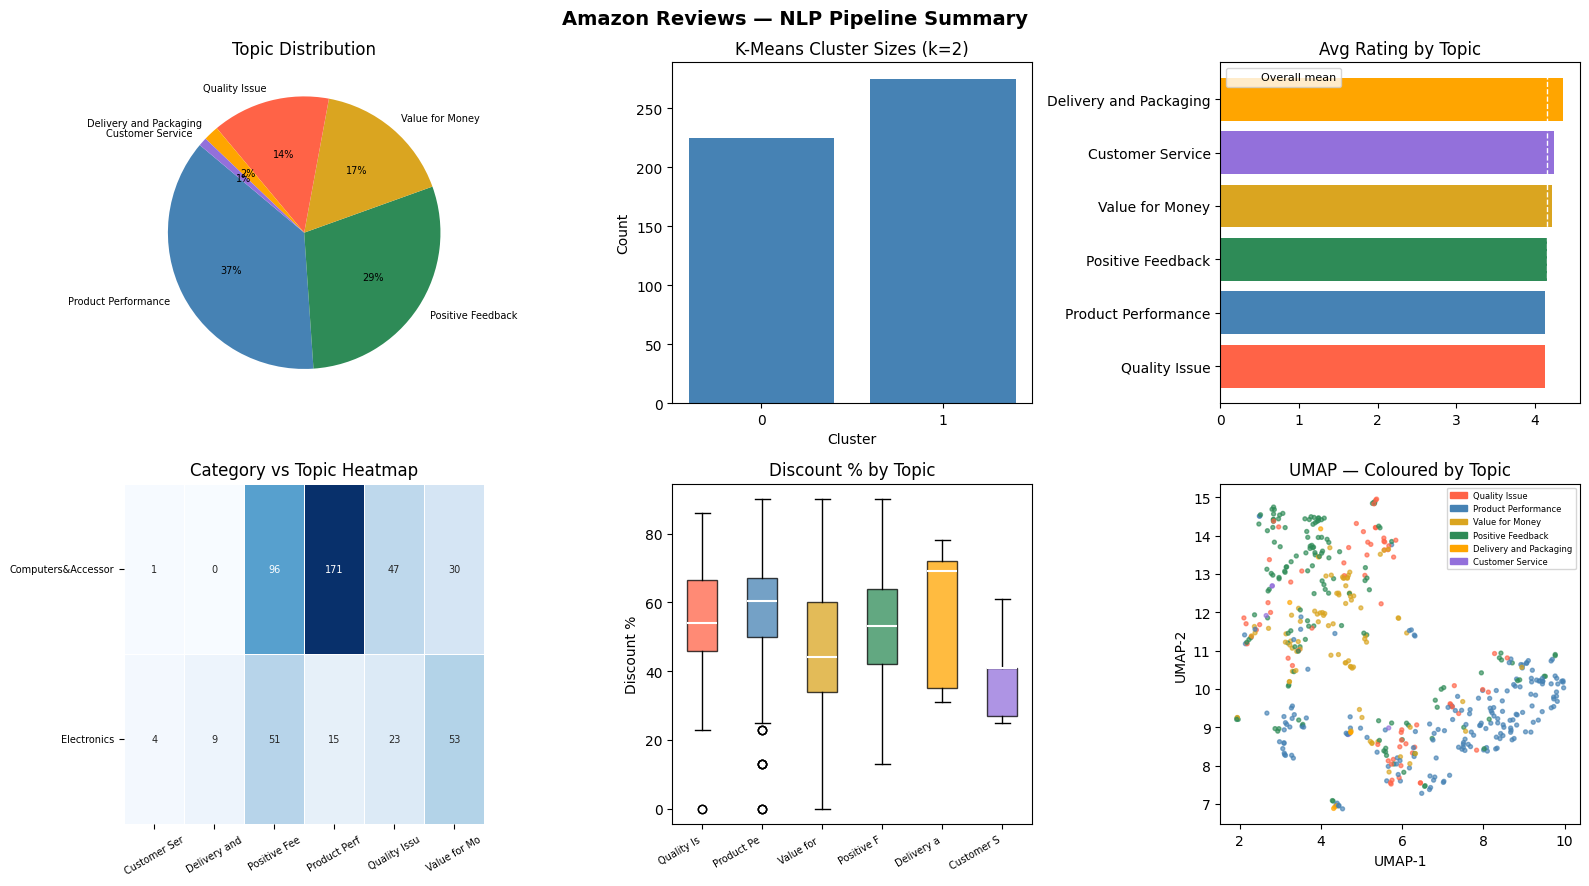

In [ ]:
# Step 14 — Summary Dashboard

# A single figure showing the key outputs of the full pipeline.

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Amazon Reviews — NLP Pipeline Summary", fontsize=14, fontweight="bold")

# Topic pie chart
td = df_work["topic"].value_counts()
axes[0, 0].pie(td.values, labels=td.index,
               colors=[TOPIC_COLORS.get(t, "grey") for t in td.index],
               autopct="%1.0f%%", textprops={"fontsize": 7}, startangle=140)
axes[0, 0].set_title("Topic Distribution")

# Cluster sizes
cs = df_work["cluster"].value_counts().sort_index()
axes[0, 1].bar(cs.index.astype(str), cs.values, color="steelblue")
axes[0, 1].set_title(f"K-Means Cluster Sizes (k={BEST_K})")
axes[0, 1].set_xlabel("Cluster")
axes[0, 1].set_ylabel("Count")

# Average rating by topic
rm = df_work.groupby("topic")["rating"].mean().sort_values()
axes[0, 2].barh(rm.index, rm.values,
                color=[TOPIC_COLORS.get(t, "grey") for t in rm.index])
axes[0, 2].axvline(df_work["rating"].mean(), color="white",
                   linestyle="--", linewidth=1, label="Overall mean")
axes[0, 2].set_title("Avg Rating by Topic")
axes[0, 2].legend(fontsize=8)

# Category vs Topic heatmap
top_cats = df_work["category"].value_counts().head(5).index
df_top   = df_work[df_work["category"].isin(top_cats)]
pivot    = pd.crosstab(df_top["category"], df_top["topic"])
pivot.columns = [c[:12] for c in pivot.columns]
pivot.index   = [i[:18] for i in pivot.index]
sns.heatmap(pivot, ax=axes[1, 0], cmap="Blues", annot=True, fmt="d",
            linewidths=0.4, cbar=False, annot_kws={"size": 7})
axes[1, 0].set_title("Category vs Topic Heatmap")
axes[1, 0].tick_params(axis="x", rotation=30, labelsize=7)
axes[1, 0].tick_params(axis="y", rotation=0,  labelsize=7)

# Discount % boxplot by topic
dn    = df_work.dropna(subset=["discount_pct"])
valid = [t for t in TOPIC_NAMES if len(dn[dn["topic"] == t]) > 0]
grps  = [dn[dn["topic"] == t]["discount_pct"].values for t in valid]
bp = axes[1, 1].boxplot(grps, patch_artist=True,
                         medianprops=dict(color="white", linewidth=1.5))
for patch, t in zip(bp["boxes"], valid):
    patch.set_facecolor(TOPIC_COLORS.get(t, "grey"))
    patch.set_alpha(0.75)
axes[1, 1].set_xticklabels([t[:10] for t in valid],
                             rotation=30, ha="right", fontsize=7)
axes[1, 1].set_title("Discount % by Topic")
axes[1, 1].set_ylabel("Discount %")

# UMAP coloured by topic
sc_cols = [TOPIC_COLORS.get(t, "grey") for t in df_work["topic"]]
axes[1, 2].scatter(df_work["umap_x"], df_work["umap_y"],
                   c=sc_cols, s=8, alpha=0.65)
patches = [mpatches.Patch(color=c, label=t)
           for t, c in TOPIC_COLORS.items() if t in df_work["topic"].values]
axes[1, 2].legend(handles=patches, fontsize=6, loc="upper right")
axes[1, 2].set_title("UMAP — Coloured by Topic")
axes[1, 2].set_xlabel("UMAP-1")
axes[1, 2].set_ylabel("UMAP-2")

plt.tight_layout()
plt.savefig("summary_dashboard.png", dpi=130, bbox_inches="tight")
plt.show()


In [29]:
# %% [markdown]
# ## Step 15 — Download All Outputs to Your Local Machine
#
# Creates a zip of all output files and downloads it directly to your browser.
# When the download completes, extract the zip into:
# D:\OneDrive - University of Arizona\Desktop\MSBA-UoA\Real Projects\NLP Based Insights

# %%
import shutil
import zipfile
from google.colab import files

# Folder inside Colab to collect everything before zipping
OUTPUT_DIR = Path("/content/nlp_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# 1. Save labelled CSV
save_cols = [
    "doc_id", "product_name", "category", "rating",
    "discounted_price", "actual_price", "discount_pct",
    "review_title", "review_content", "text", "clean_text",
    "cluster", "topic"
]
df_work[save_cols].to_csv(OUTPUT_DIR / "amazon_reviews_labelled.csv",
                          index=False, encoding="utf-8")
print(f"[1] amazon_reviews_labelled.csv  ({len(df_work)} rows)")

# 2. Save cluster keywords JSON
with open(OUTPUT_DIR / "cluster_keywords.json", "w", encoding="utf-8") as f:
    json.dump({str(k): v for k, v in cluster_keywords.items()}, f, indent=2)
print("[2] cluster_keywords.json")

# 3. Copy all charts into the output folder
chart_files = [
    "eda_overview.png",
    "top30_tokens.png",
    "embedding_vectors.png",
    "elbow_silhouette.png",
    "semantic_search.png",
    "topic_distribution.png",
    "summary_dashboard.png",
    "umap_clusters.html",
]

for chart in chart_files:
    src = Path(chart)
    if src.exists():
        shutil.copy2(src, OUTPUT_DIR / chart)
        print(f"[3] {chart}")
    else:
        print(f"    skipped (not found): {chart}")

# 4. Zip everything
zip_path = "/content/NLP_Amazon_Outputs.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for f in sorted(OUTPUT_DIR.iterdir()):
        if f.is_file():
            zf.write(f, f.name)
            print(f"    added to zip: {f.name}")

print(f"\nZip size: {Path(zip_path).stat().st_size / 1024:.1f} KB")
print("Downloading now...")

# 5. Download the zip — it goes to your browser's default Downloads folder
files.download(zip_path)

print("\nDone. When download completes:")
print("  1. Find NLP_Amazon_Outputs.zip in your Downloads folder")
print("  2. Right-click it -> Extract All")
print(r"  3. Extract to: D:\OneDrive - University of Arizona\Desktop\MSBA-UoA\Real Projects\NLP Based Insights")

[1] amazon_reviews_labelled.csv  (500 rows)
[2] cluster_keywords.json
[3] eda_overview.png
[3] top30_tokens.png
[3] embedding_vectors.png
[3] elbow_silhouette.png
[3] semantic_search.png
[3] topic_distribution.png
[3] summary_dashboard.png
[3] umap_clusters.html
    added to zip: amazon_reviews_labelled.csv
    added to zip: cluster_keywords.json
    added to zip: eda_overview.png
    added to zip: elbow_silhouette.png
    added to zip: embedding_vectors.png
    added to zip: semantic_search.png
    added to zip: summary_dashboard.png
    added to zip: top30_tokens.png
    added to zip: topic_distribution.png
    added to zip: umap_clusters.html

Zip size: 1933.4 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done. When download completes:
  1. Find NLP_Amazon_Outputs.zip in your Downloads folder
  2. Right-click it -> Extract All
  3. Extract to: D:\OneDrive - University of Arizona\Desktop\MSBA-UoA\Real Projects\NLP Based Insights
